In [1]:
# load functions
import numpy as np
import pandas as pd
import random
import seaborn as sns 
import os
import forestplot as fp
import re

random.seed(7)

from src.utils import get_data, get_nn_output
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sksurv.metrics import concordance_index_censored
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from functools import reduce
from lifelines import CoxPHFitter
from statsmodels.api import OLS, Logit, add_constant
from statsmodels.stats.weightstats import ztest as ztest
from scipy.stats import norm, wilcoxon, shapiro

## Elastic nets

In [2]:
def calculate_biomarkers(protein_df, coefficients_df, name_col, weight_col):
    # Map proteins to coefficients (protein names are keys, coefficients are values)
    coefficient_dict = coefficients_df.set_index(name_col)[weight_col].to_dict()
    
    # Identify the common proteins
    common_proteins = protein_df.columns.intersection(coefficient_dict.keys())
    
    # Multiply protein by weight
    weighted_values = protein_df[common_proteins].mul([coefficient_dict[protein] for protein in common_proteins], axis=1)
    
    # Create sumscore
    sumscore = weighted_values.sum(axis=1)
    
    return sumscore

In [3]:
#Read in standardized proteins
rs_olink = pd.read_csv('Data/RS/RS_olink_imputed.csv')

#calculate age as time between birth and blood-sampling and scale
rs_age = pd.read_spss('Data/RS/RoterdamStudy_Basics2014.sav')
rs_bld = pd.read_spss('Data/RS/e5_(5)_BLDAFNAM_(10-jul-2017).sav')
rs_bld = rs_bld.rename(columns={'e5_2686': 'blooddate'})
rs_bld = rs_bld[['ergoid', 'blooddate']]

rs_age = rs_age.merge(rs_bld, how = 'inner')
rs_age['age_raw'] = (pd.to_datetime(rs_age['blooddate']) - pd.to_datetime(rs_age['date_of_birth']) )/ pd.Timedelta('365 days')

#Make sex same as UKBB
rs_age['sex'] = np.where(rs_age['sex'] == 'male', 1, 0)

#Merge with bigger file
rs = pd.merge(rs_olink, rs_age[['ergoid','age_raw', 'blooddate', 'sex']], how = 'left', left_on='SampleID', right_on='ergoid')
rs.drop('SampleID', axis=1, inplace = True)

#Scale age for biomarker creation
scaler = StandardScaler()      
rs['age'] = scaler.fit_transform(rs['age_raw'].values.reshape(-1,1))

#save for later usage
rsnn = rs

In [4]:
def process_en_models(directory, target, set3_df, id_col):
    # Loop through selected models directory
    for file in os.listdir(directory):
        if file.endswith(".csv"):
            file_name = os.path.splitext(file)[0]  # remove .csv
            file_path = os.path.join(directory, file)
            weights_df = pd.read_csv(file_path)  # Load the weights DataFrame

            # Find the dset using regular expression
            match = re.search(rf'{target}_cmb(.*?)_?(?:ffs)?$', file_name)
            if match:
                # Call function to create pandas DataFrame from the model type and matched group
                set3_model = set3_df
                set3_model[file_name] = calculate_biomarkers(set3_df, weights_df, weights_df.columns[0], weights_df.columns[1])

                # Merge with set3_df
                set3_df = pd.merge(set3_df, set3_model[[id_col, file_name]], how='outer')
            else:
                print(f'Not the right way to do this, error is for {target} and {file_name}!')
    return set3_df

In [5]:
#Elastic net biomarkers
frailty_en_directory = os.path.join('output_linear/coefs_frail/selected_models/')
mort_en_directory = os.path.join('output_linear/coefs_mort/selected_models/')
rs_df = process_en_models(frailty_en_directory, 'frailty', rs, 'ergoid')
rs_df = process_en_models(mort_en_directory, 'mort', rs_df, 'ergoid')
rs_df.index = rs_df['ergoid']
rs_df = rs_df.loc[:, rs_df.columns.str.startswith('combine_')]
rs_df.columns = rs_df.columns.str.removeprefix("combine_")

Not the right way to do this, error is for frailty and combine_coefs_frailty_allprot!
Not the right way to do this, error is for mort and combine_coefs_mort_allprot!


## Neural nets

In [6]:
# Get set and give column right name for joining
def assign_nn_out(data_frame, model_path, dataset_type, target, id_colname):
    _, _, _, _, _, _, cols = get_data({'dset': dataset_type, 'target': target, 'combine_sets':False})
    colskeep = cols[:-1]
    data_index = data_frame[id_colname].to_numpy()
    data_array = data_frame[colskeep].to_numpy()
    var_name = f'nn_pred_{dataset_type}_{target}'
    df = get_nn_output(data_array, model_path, dataset_type, target, data_index = data_index)
    df.columns = [f'nn_{dataset_type}_{target}']
    globals()[var_name] = df

In [7]:
#Neural net biomarkers
#Mortalty
rsnn['age_center.0.0'] = rsnn['age']
assign_nn_out(rsnn, "nn_models/model_i4uflnuh.pt", 'cmb', 'mort', 'ergoid')
assign_nn_out(rsnn, "nn_models/model_77k50cmg.pt", 'cmb_ffs', 'mort', 'ergoid')

#Frailty
assign_nn_out(rsnn, "nn_models/model_qjtdn71n.pt", 'cmb', 'frailty', 'ergoid')
assign_nn_out(rsnn, "nn_models/model_dbwxpwou.pt", 'cmb_ffs', 'frailty', 'ergoid')

In [8]:
# Merge mortality and frailty datasets then combine
nn_pred_cmb_mortality = reduce(lambda left, right: pd.merge(left, right, left_index=True, right_index=True, how='outer'), 
                               [v for k, v in globals().items() if k.startswith('nn_') and k.endswith('_mort')])
nn_pred_cmb_frailty = reduce(lambda left, right: pd.merge(left, right, left_index=True, right_index=True, how='outer'), 
                             [v for k, v in globals().items() if k.startswith('nn_') and k.endswith('_frailty')])
nn_combined_data = pd.merge(nn_pred_cmb_mortality, nn_pred_cmb_frailty, left_index=True, right_index=True, how='outer')

## Other biomarkers

In [9]:
batch1 = pd.read_csv('Data/RS/raw_batch1_incladdedclocks.csv')
batch2 = pd.read_csv('Data/RS/raw_batch2_incladdedclocks.csv')
dnam = batch1.merge(batch2, how='outer')
dnam.index = dnam['ergoid']

dnam = dnam[['Horvath', 'DNAmHannumAge', 
       'DNAmGrimAge', 'mortScore']]

## Demographics and lifestyle factors

In [10]:
# Function to make one big dataframe
def load_and_prepare(file_path, index_col='ergoid', join_columns=None, rename_columns=None, calc_columns=None):
    # Load data
    if file_path.endswith('.sav'):
        df = pd.read_spss(file_path)
    elif file_path.endswith('.csv') or file_path.endswith('.txt'):
        df = pd.read_csv(file_path, sep="\t" if file_path.endswith('.txt') else ",")
    else:
        raise ValueError("Unsupported file format")
    
    # Set index
    df.set_index(index_col, inplace=True)
    
    # Rename columns
    if rename_columns:
        df.rename(columns=rename_columns, inplace=True)
    
    # Calculate new columns
    if calc_columns:
        for col_name, calc_func in calc_columns.items():
            df[col_name] = calc_func(df, age)  # Pass `age` dataframe for calculations if needed
    
    # Select specified columns
    if join_columns:
        df = df[join_columns]
    
    return df

# Define datasets with their processing instructions
datasets = [
    {
        "file_path": "Data/RS/fp_VitalStatus_2024-26.sav",
        "calc_columns": {
            #Make follow-up time as time between blood sampling and censoring
            #Censor age as time between blood sampling and censoring + chronological age to account for left censoring
            "followup": lambda df, age: (pd.to_datetime(df['fp_censordate']) - pd.to_datetime(age['blooddate'])) / pd.Timedelta('365 days'),
            "censorage": lambda df, age: (pd.to_datetime(df['fp_censordate']) - pd.to_datetime(age['blooddate'])) / pd.Timedelta('365 days') + age['age_raw'],
            "died": lambda df, _: np.where(df['fp_vitalstatus'] == 'dead', 1, 0)
        },
        "join_columns": ["followup", "censorage", "died"]
    },
    {
        "file_path": "Data/RS/RS_CHD.csv",
        "calc_columns": {
            #Make follow-up time as time between blood sampling and censoring
            #Censor age as time between blood sampling and censoring + chronological age to account for left censoring
            "CVD_followup": lambda df, age: (pd.to_datetime(df['enddate_CHD']) - pd.to_datetime(age['blooddate'])) / pd.Timedelta('365 days'),
            "CVD_age": lambda df, age: (pd.to_datetime(df['enddate_CHD']) - pd.to_datetime(age['blooddate'])) / pd.Timedelta('365 days') + age['age_raw']
        },
        "rename_columns": {"inc_CHD": "CVD_inc", "prev_CHD":"CVD_prev"},
        "join_columns": ["CVD_followup", "CVD_age", "CVD_inc", "CVD_prev"]
    },
    
    {"file_path": "Data/RS/Frailty_E5.txt", 
     "join_columns": ["FI", "FRIED", "TFI", "CHARGE", "MPI", "TFIC", "FRIED5"]},
    {
        "file_path": "Data/RS/e5_(5)_ANTHROPO_(10-dec-2015).sav",
        #Calculate bmi as weight (kg)/height (m)^2
        "calc_columns": {"bmi": lambda df, _: df['e5_230'].astype(float) / (df['e5_229'].astype(float) / 100) ** 2},
        "join_columns": ["bmi"]
    },
    {
        "file_path": "Data/RS/e5_intvw_SMOKING_(22-mar-2021).sav",
        "calc_columns": {
            #Make smoking cigarettes binary but only for people that answered.
         "smokingyn": lambda df, _: np.where(
            (df['e5_EILF6'] == 'ja') & (~df['e5_EILF6'].isin(['weet het niet', 'geen antwoord'])), 1, 0)},
        "join_columns": ["smokingyn"]
    },
    {
        "file_path": "Data/RS/HT2018_analysisfile_(15-may-2018).sav",
        "calc_columns": {"hbp": lambda df, _: np.where(df['e5_HT2018'] == 'yes', 1, 0)},
        "join_columns": ["hbp"]
    },
    {
        "file_path": "Data/RS/Education RS-I-II-III (UNESCO class)_(12-MAR-2015).sav",
         #Use more interpretable name for ses
        #"rename_columns": {"ses_UNESCO_recoded": "ses"},
        "join_columns": ["ses_UNESCO_recoded"]
    },
    {"file_path": "Data/RS/RSI-5_RSII-3_RSIII-2_handgrip.sav", 
     "join_columns": ["max_handgrip"]},
    {"file_path": "Data/RS/e5_(5)_LAB_(29-aug-2014).sav",
     #Use more interpretable names for cell counts
     "rename_columns": {"e5_12794": "lymph_perc", "e5_12801" : "mono_perc"},
     "join_columns": ["lymph_perc", "mono_perc"]
    },
    {"file_path" : "Data/RS/e5_intvw_PAINPERC_(25-apr-2019).sav",
     "calc_columns": {
          #Make variable poor health for people who believed their health was poor compared to peers but not when didn't know or didn't answer
         "poor_health": lambda df, _: np.where(
            (df['e5_EIGEZLFT'] == 'slechter') & (~df['e5_EIGEZLFT'].isin(['Weet het niet', 'missing'])), 1, 0)},
     "join_columns": ["poor_health"]}
        
]

#Age 
rs.set_index('ergoid', inplace = True)
age = rs[['age_raw', 'blooddate', 'sex']]

# Want to left_join with age so start with that
cov_data = age.copy()

# Iteratively merge each dataset
for dataset in datasets:
    df = load_and_prepare(
        file_path=dataset["file_path"],
        join_columns=dataset.get("join_columns"),
        rename_columns=dataset.get("rename_columns"),
        calc_columns=dataset.get("calc_columns")
    )
    cov_data = cov_data.merge(df, how='left', left_index=True, right_index=True)

cov_data['lymph_perc'] = cov_data['lymph_perc'].astype('float')
cov_data['mono_perc'] = cov_data['mono_perc'].astype('float')

# SES disturbs the rest try differently
ses_mapping = {
    'higher vocational education OR university': 0,
    'lower/intermediate general education OR lower vocational education': 1,
    'intermediate vocational education OR higher general education': 2,
    'primary education': 3
}

# Apply the mapping to the ses column
cov_data['ses'] = cov_data['ses_UNESCO_recoded'].map(ses_mapping)


In [11]:
#Make one giant dataframe
dfs_to_merge = [rs_df, nn_combined_data, rs['GDF15'], cov_data]
own_df = reduce(lambda left, right: pd.merge(left, right, left_index=True, right_index=True), dfs_to_merge)
own_df.head()

compare_df = own_df.merge(dnam, how = 'left', left_index = True, right_index = True)

# Correlation

In [12]:
dfs_to_cor = [rs_df, nn_combined_data, dnam, rs['GDF15'], age]
cor_df = reduce(lambda left, right: pd.merge(left, right, left_index=True, right_index=True), dfs_to_cor)
cor_df.dropna(how='any', inplace=True)

# Save columns with biomarkers
protein_columns = [col for col in cor_df.columns if col.startswith('coefs_') or col.startswith('nn_') or col in dnam.columns or col == 'PAC' or col == 'GDF15' or col == 'mortScore']

# Linear regression for each column
for col in protein_columns:
    # Extracting X (age) and y (the column to regress on)     
    X = cor_df['age_raw'].values.reshape(-1, 1)     
    y = cor_df[col].values.reshape(-1, 1)
    
    # Fitting linear regression model to determine Age Acceleration
    aa_model = LinearRegression()
    aa_model.fit(X, y)
    
    # Calculating residuals
    residuals = y - aa_model.predict(X)
    
    # Creating new column for residuals
    new_col_name = 'aa_' + col
    cor_df[new_col_name] = residuals

Index(['aa_coefs_frailty_cmb_ffs', 'aa_coefs_frailty_cmb', 'aa_coefs_mort_cmb',
       'aa_coefs_mort_cmb_ffs', 'aa_nn_cmb_mort', 'aa_nn_cmb_ffs_mort',
       'aa_nn_cmb_frailty', 'aa_nn_cmb_ffs_frailty', 'aa_Horvath',
       'aa_DNAmHannumAge', 'aa_DNAmGrimAge', 'aa_mortScore', 'aa_GDF15'],
      dtype='object')


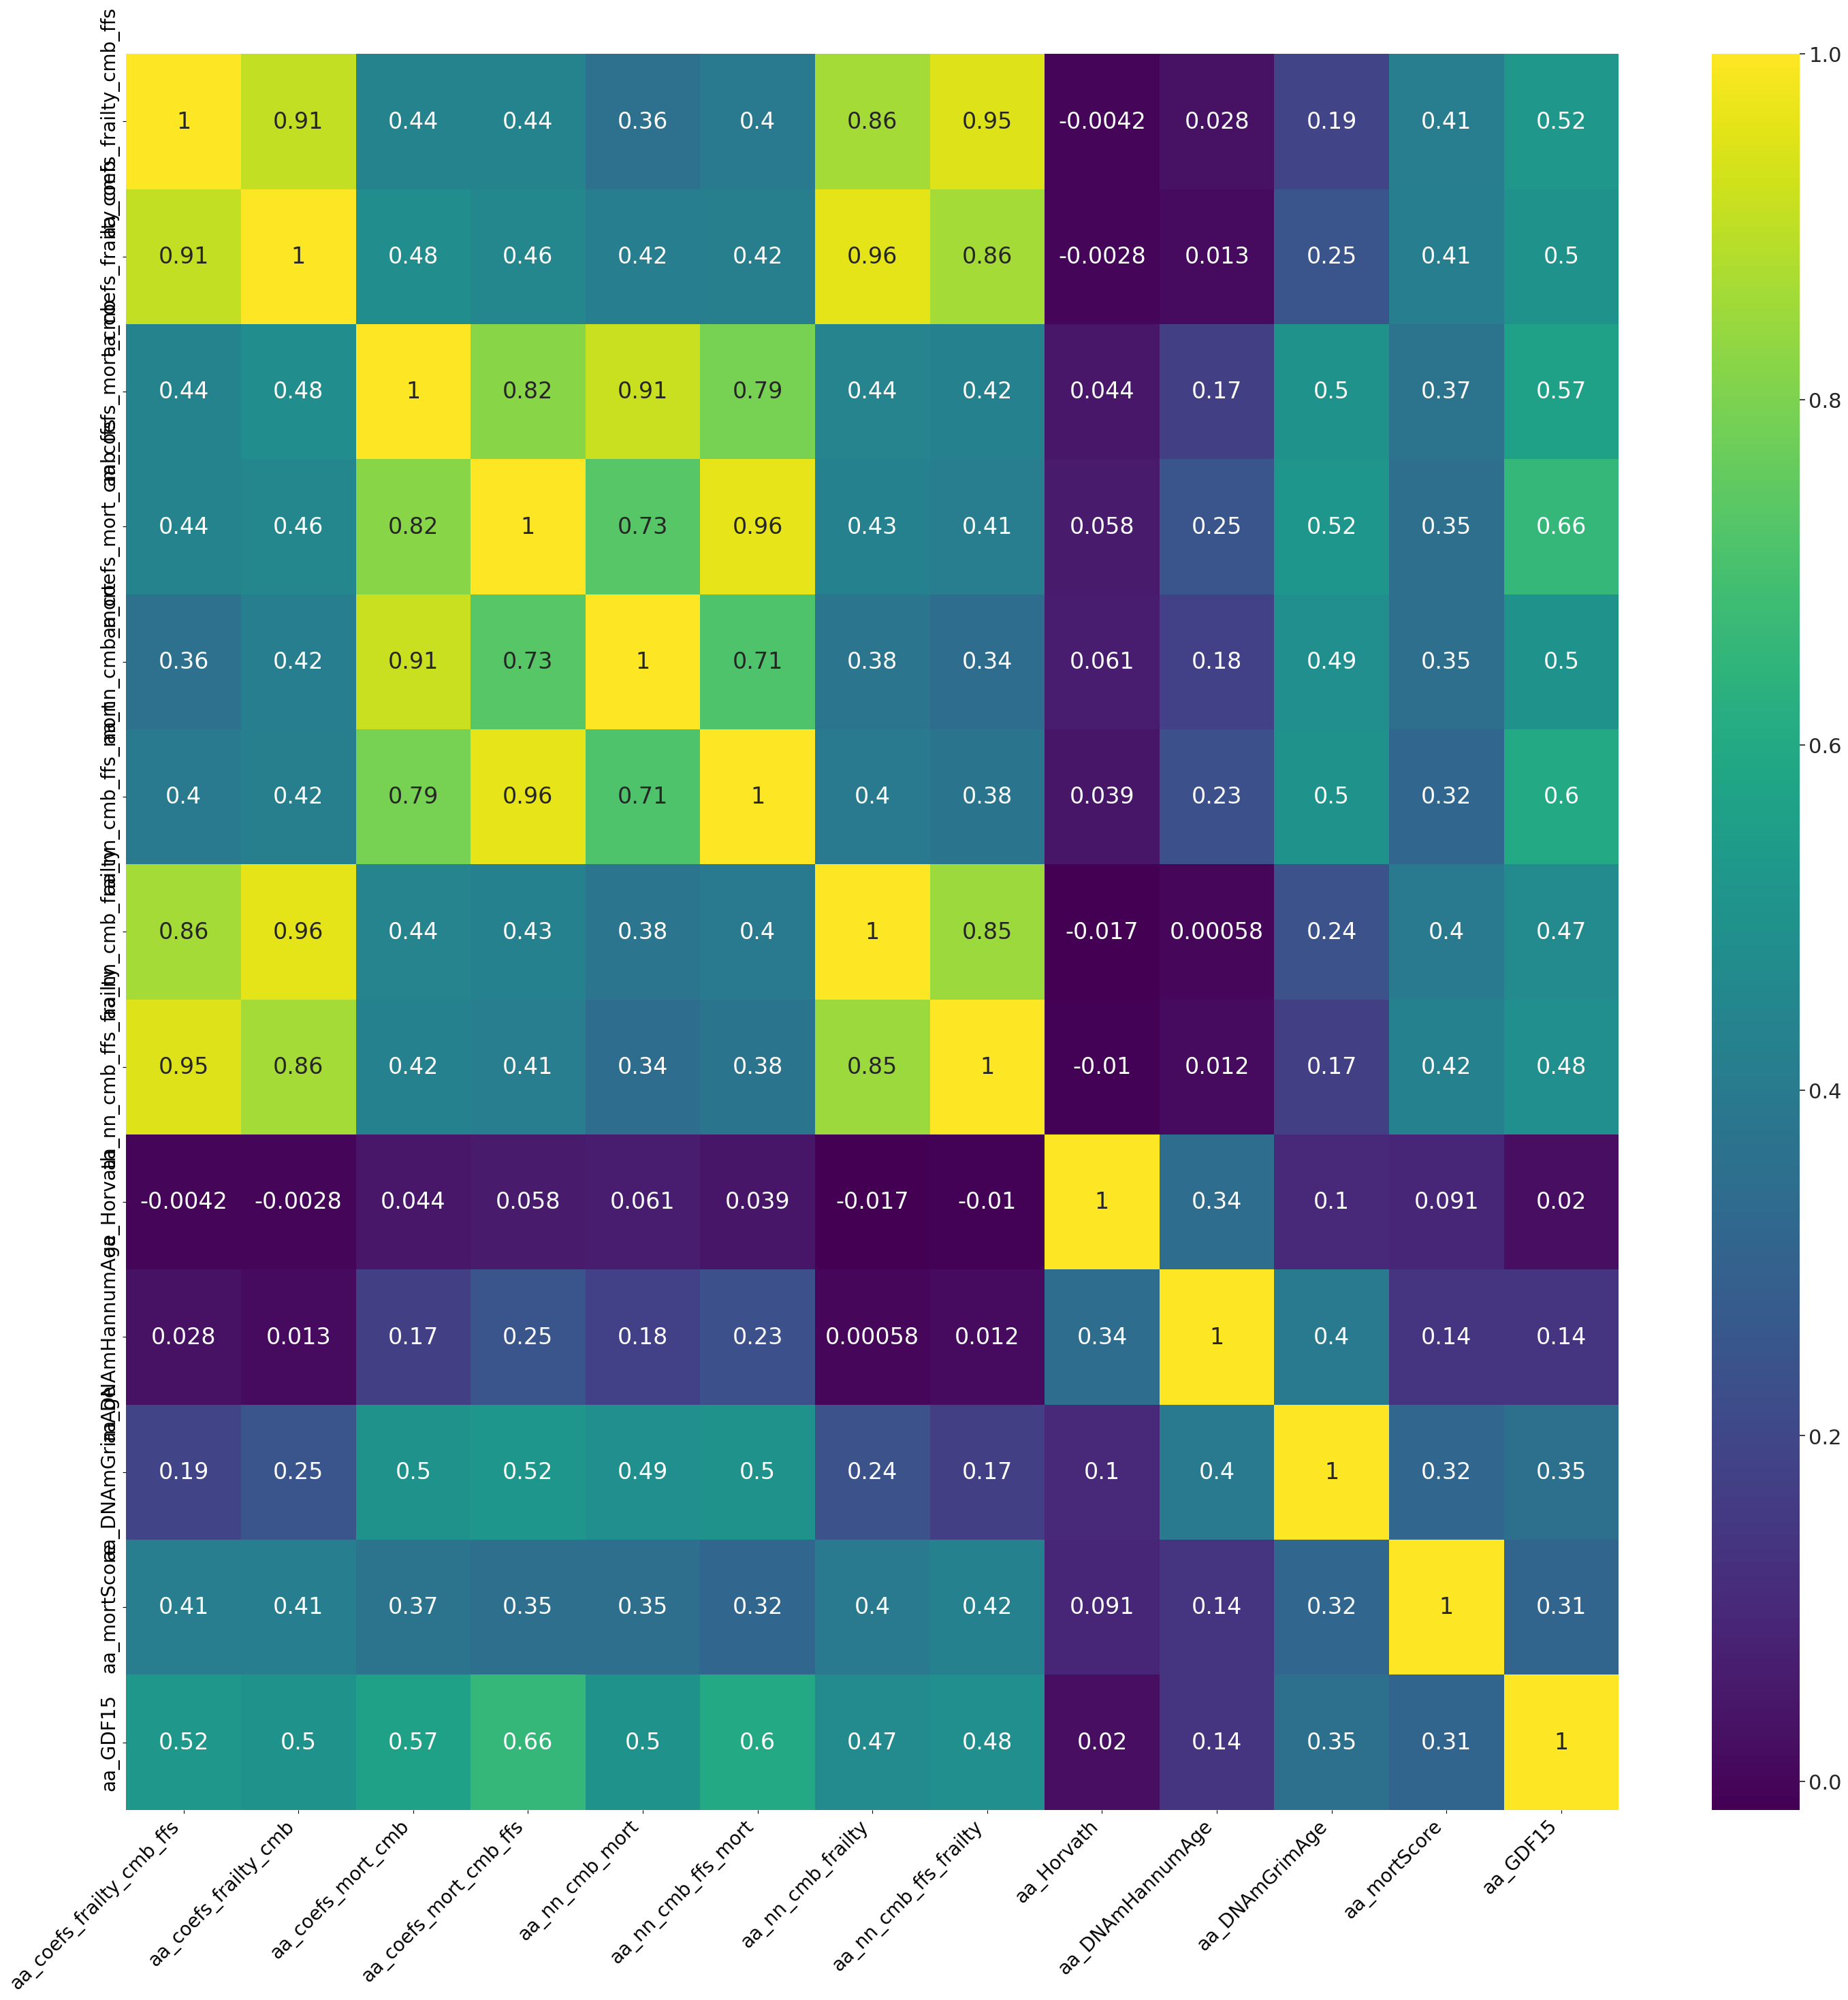

In [13]:
corraabiomarkers = cor_df.drop(columns=[col for col in cor_df.columns if not col.startswith('aa_')])
corraabiomarkers.columns = map(lambda x: x.replace('_proteins', ''), corraabiomarkers.columns)
print(corraabiomarkers.columns)

#corraabiomarkers_new = corraabiomarkers.reindex(columns = ['age', 'en_mort_all', 'en_mort_cmb', 'nnet_cmb', 'en_fi_all', 'en_fi_cmb','aa_en_mort_all', 'aa_en_mort_cmb', 'aa_nnet_cmb', 'aa_en_fi_all', 'aa_en_fi_cmb']).corr(method='spearman')
corraabiomarkers_cor = corraabiomarkers.corr(method='spearman')

# Create heatmap
# Generate a mask for the upper triangle
# mask = np.triu(np.ones_like(corraabiomarkers_new, dtype=bool))
fig, ax = plt.subplots(figsize=(30, 30))  # Adjust the size as per your preference
sns.set(font_scale=2)
corraabiomarkers_plot = sns.heatmap(corraabiomarkers_cor, cmap="viridis", annot=True, ax=ax)
plt.yticks(fontsize=20) 
plt.xticks(fontsize=20,rotation=45, ha='right') 
plt.tight_layout()

# Display the plot
plt.show()
#plt.savefig("correlations_set3.svg", backend='svg', transparent=True)

# Cox-PH regression on overall-mortality

In [14]:
compare_df.shape

(996, 39)

In [15]:
# Mortality analyses
# Initialize CoxPHFitter
compare_df['age'] = compare_df['age_raw']
cph_lifelines = CoxPHFitter()

# Event variables
events = [['died'], ['CVD_inc']]
censorage = [['censorage'], ['CVD_age']]

# Prepare dataframe for coefficients
coefs = pd.DataFrame(columns=['outcome', 'variable', 'model', 'covariates', 'N', 'N_event', 'coef', 'se(coef)', 'exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p', 'C', 'CompareExternal',
                              'Biomarker2', 'Biomarker2_coef', 'Biomarker2_HR', 'Biomarker2_LL', 'Biomarker2_UL', 'Biomarker2_p'])

# Additional columns to consider
additional_columns = [[], ['sex'], ['sex', 'ses'], ['sex', 'ses', 'smokingyn', 'bmi'], ['sex', 'ses', 'smokingyn', 'bmi', 'lymph_perc', 'mono_perc']]

# Add MetaboHealth and GDF15 for comparison
with_MetaboHealth = [['mortScore'] + sublist for sublist in additional_columns]
with_GDF15 = [['GDF15'] + sublist for sublist in additional_columns]
additional_columns.extend(with_MetaboHealth)
additional_columns.extend(with_GDF15)

# Initialize scaler
scaler = StandardScaler()

# Iterate through columns
for comparebiomarker in [False, True]:
    for column in compare_df.columns:
        if column.startswith('coefs_') or column.startswith('nn_') or column == 'GDF15' or column in dnam.columns:
            for o in range(len(events)):
                for i in range(len(additional_columns)):
                    
                    # Skip if the column is 'GDF15' and 'GDF15' is in additional_columns[i]
                    if column == 'GDF15' and 'GDF15' in additional_columns[i]:
                        continue  # Skip this iteration
    
                    if column == 'mortScore' and 'mortScore' in additional_columns[i]:  # Skip if matching mortScore
                        continue

                    # Drop rows with NaN values based on comparebiomarkers flag
                    if comparebiomarker:
                        compare_mortality = compare_df.dropna(
                            subset=[column for column in compare_df.columns 
                                    if column.startswith('coefs_') 
                                    or column.startswith('nn_') 
                                    or column in dnam.columns], inplace=False)
                    else:
                        compare_mortality = compare_df.dropna(
                            subset=[column for column in compare_df.columns 
                                    if column.startswith('coefs_') 
                                    or column.startswith('nn_') ], inplace=False)
    
                    # Drop rows with NaN values for the relevant columns
                    compare_df2 = compare_mortality.dropna(subset=[column] + additional_columns[i] + ['age'] + events[o] + censorage[o])
    
                    # Prepare model data
                    model_data = compare_df2[[column] + additional_columns[i] + ['age'] + events[o] + censorage[o]].copy()
                    model_data.dropna(how='any', inplace=True)
                    
                    if i != 0:
                        Xres = model_data['age'].values.reshape(-1, 1)     
                        yres = model_data[column].values.reshape(-1, 1)
                        # Fitting linear regression model to determine Age Acceleration
                        aa_model = LinearRegression()
                        aa_model.fit(Xres, yres)
    
                        # Calculating residuals
                        residuals = yres - aa_model.predict(Xres)
            
                        # Creating new column for residuals
                        model_data[[column]] = residuals
                

                    # If 'mortScore' or 'GDF15' is in the model, handle residuals
                    if 'mortScore' in additional_columns[i] or 'GDF15' in additional_columns[i]:
                        biomarker = 'mortScore' if 'mortScore' in additional_columns[i] else 'GDF15'
                        X_biomarker = model_data['age'].values.reshape(-1, 1)
                        y_biomarker = model_data[biomarker].values.reshape(-1, 1)

                        aa_modelbiom2 = LinearRegression()
                        aa_modelbiom2.fit(X_biomarker, y_biomarker)
                        residualsbiom2 = y_biomarker - aa_modelbiom2.predict(X_biomarker)
                        # Adding residuals to the model data
                        model_data[biomarker] = residualsbiom2
                        model_data[biomarker] = scaler.fit_transform(model_data[[biomarker]])

                    # Scale the column of interest
                    model_data[column] = scaler.fit_transform(model_data[[column]])
                    model_data.drop('age', axis=1, inplace=True)

                    # Fit the Cox model
                    cph_lifelines.fit(model_data, censorage[o][0], events[o][0])

                    # Get summary data
                    summary = cph_lifelines.summary

                    # Extract coefficients for the column of interest
                    coef_values = summary.loc[[column], ['coef', 'se(coef)', 'exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']].copy()

                    # Add additional information
                    coef_values['outcome'] = events[o][0]
                    coef_values['variable'] = f'aa_{column}'
                    coef_values['model'] = i
                    coef_values['N'] = len(cph_lifelines.durations)
                    coef_values['N_event'] = cph_lifelines.event_observed.sum()
                    coef_values['C'] = cph_lifelines.concordance_index_
                    coef_values['CompareExternal'] = comparebiomarker
                
                    if additional_columns[i]:
                        coef_values['covariates'] = ', '.join(additional_columns[i])  # Combine list into a single string for readability
                    else:
                        coef_values['covariates'] = 'None Not Age Accelerated' 

                    # If 'mortScore' or 'GDF15' is part of the model, extract and add related information
                    if 'mortScore' in additional_columns[i]:
                        mh_values = summary.loc[['mortScore'], ['coef', 'se(coef)', 'exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']].copy()
                        coef_values['Biomarker2'] = biomarker
                        coef_values['Biomarker2_coef'] = mh_values['coef'].iloc[0]
                        coef_values['Biomarker2_HR'] = mh_values['exp(coef)'].iloc[0]
                        coef_values['Biomarker2_LL'] = mh_values['exp(coef) lower 95%'].iloc[0]
                        coef_values['Biomarker2_UL'] = mh_values['exp(coef) upper 95%'].iloc[0]
                        coef_values['Biomarker2_p'] = mh_values['p'].iloc[0]
                    elif 'GDF15' in additional_columns[i]:
                        gdf_values = summary.loc[['GDF15'], ['coef', 'se(coef)', 'exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']].copy()
                        coef_values['Biomarker2'] = biomarker
                        coef_values['Biomarker2_coef'] = gdf_values['coef'].iloc[0]
                        coef_values['Biomarker2_HR'] = gdf_values['exp(coef)'].iloc[0]
                        coef_values['Biomarker2_LL'] = gdf_values['exp(coef) lower 95%'].iloc[0]
                        coef_values['Biomarker2_UL'] = gdf_values['exp(coef) upper 95%'].iloc[0]
                        coef_values['Biomarker2_p'] = gdf_values['p'].iloc[0]
                    else:
                        coef_values['Biomarker2'] = np.nan
                        coef_values['Biomarker2_coef'] = np.nan
                        coef_values['Biomarker2_HR'] = np.nan
                        coef_values['Biomarker2_LL'] = np.nan
                        coef_values['Biomarker2_UL'] = np.nan
                        coef_values['Biomarker2_p'] = np.nan
                    

                    # Reorder columns and append to coefs dataframe
                    coef_values = coef_values[['outcome', 'variable', 'model', 'covariates', 'N', 'N_event', 'coef', 'se(coef)', 'exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p', 'C', 'CompareExternal',
                                            'Biomarker2', 'Biomarker2_coef', 'Biomarker2_HR', 'Biomarker2_LL', 'Biomarker2_UL', 'Biomarker2_p']]
                    coefs = pd.concat([coefs, coef_values], ignore_index=True)

# Display or return the coefficients dataframe
coefs['HR_CI'] = coefs.apply(lambda row: f"{round(row['exp(coef)'], 2)} ({round(row['exp(coef) lower 95%'], 2)}; {round(row['exp(coef) upper 95%'], 2)})", axis=1)
coefs['Biomarker2_CI'] = coefs.apply(lambda row: f"{round(row['Biomarker2_HR'], 2)} ({round(row['Biomarker2_LL'], 2)}; {round(row['Biomarker2_UL'], 2)})", axis=1)
coefs['Concordance'] = round(coefs['C'], 2)

print("Final Coefficients DataFrame:")
print(coefs)

coefs.to_csv('intermediate_results/RS_mortality.csv', index=False)


Final Coefficients DataFrame:
     outcome                  variable model  \
0       died  aa_coefs_frailty_cmb_ffs     0   
1       died  aa_coefs_frailty_cmb_ffs     1   
2       died  aa_coefs_frailty_cmb_ffs     2   
3       died  aa_coefs_frailty_cmb_ffs     3   
4       died  aa_coefs_frailty_cmb_ffs     4   
..       ...                       ...   ...   
735  CVD_inc              aa_mortScore    10   
736  CVD_inc              aa_mortScore    11   
737  CVD_inc              aa_mortScore    12   
738  CVD_inc              aa_mortScore    13   
739  CVD_inc              aa_mortScore    14   

                                            covariates    N N_event      coef  \
0                             None Not Age Accelerated  996      68  0.575318   
1                                                  sex  996      68  0.657258   
2                                             sex, ses  993      68  0.707764   
3                             sex, ses, smokingyn, bmi  993      68  

In [16]:
# Frailty
compare_df.drop('age', inplace = True, axis = 1)
# Define the outcomes and risk factors
true_outcomes = [['FI'], ['CVD_prev'], ['hbp'], ['max_handgrip'], ['poor_health']]
riskfact = [['smokingyn'], ['bmi']]
outcomes = true_outcomes + riskfact
print(outcomes)

# Define additional columns to consider
frailty_additional_columns = [
    
    ['age'],
    ['age', 'sex'],
    ['age', 'sex', 'ses'],
    ['age', 'sex', 'ses', 'smokingyn', 'bmi'],
    ['age', 'sex', 'ses', 'smokingyn', 'bmi', 'lymph_perc', 'mono_perc']
]

# Add MetaboHealth and GDF15 for comparison
with_MetaboHealth_frailty = [['mortScore'] + sublist for sublist in frailty_additional_columns]
with_GDF15_frailty = [['GDF15'] + sublist for sublist in frailty_additional_columns]

frailty_additional_columns.extend(with_MetaboHealth_frailty)
frailty_additional_columns.extend(with_GDF15_frailty)

# Initialize the scaler for normalization
scaler = StandardScaler()

# Store the results
results = []

# Iterate through columns in compare_frailty (comparebiomarkers)
for comparebiomarkers in [True, False]:
    for out in outcomes:
        for column in compare_df.columns:
            if column.startswith('coefs_') or column.startswith('nn_') or column in dnam.columns or column == 'GDF15' or column == 'mortScore':
                
                # Loop through the additional columns
                for i in range(len(frailty_additional_columns)):
                    
                    # Skip adjusting mortScore for mortScore
                    if column == 'mortScore' and 'mortScore' in frailty_additional_columns[i]:
                        continue
                    
                    # Skip adjusting GDF15 for GDF15
                    if column == 'GDF15' and 'GDF15' in frailty_additional_columns[i]:
                        continue
                    
                    # Drop rows with NaN values based on comparebiomarkers flag
                    if comparebiomarkers:
                        compare_frailty = compare_df.dropna(
                            subset=[column for column in compare_df.columns 
                                    if column.startswith('coefs_') 
                                    or column.startswith('nn_') 
                                    or column in dnam.columns], inplace=False)
                    else:
                        compare_frailty = compare_df.dropna(
                            subset=[column for column in compare_df.columns 
                                    if column.startswith('coefs_') 
                                    or column.startswith('nn_') ], inplace=False)
                    
                    compare_frailty.rename(columns={'age_raw':'age'}, inplace=True)
                    
                    # Check if the outcome exists in the additional columns
                    if len(set(out).intersection(set(frailty_additional_columns[i]))) == 0:
                        frailty_add = list(np.append(out, frailty_additional_columns[i]))
                        model_data = compare_frailty[[column] + frailty_add].copy()
                    else:
                        model_data = compare_frailty[[column] + frailty_additional_columns[i]].copy()
                        model_data = model_data.reindex(columns=(out + list([a for a in model_data.columns if a != out[0]])))

                    # Drop rows with NaN values
                    model_data.dropna(how='any', inplace=True)

                    if i != 0:
                        # Extracting X (age) and y (the column to regress on)
                        Xres = model_data['age'].values.reshape(-1, 1)
                        yres = model_data[column].values.reshape(-1, 1)
                        
                        # Fitting linear regression model to determine Age Acceleration
                        aa_model = LinearRegression()
                        aa_model.fit(Xres, yres)

                        # Calculating residuals
                        residuals = yres - aa_model.predict(Xres)

                        # Creating new column for residuals
                        model_data[[column]] = residuals
                    
                        # Adjust for mortScore or GDF15 if present in the columns
                        if 'mortScore' in frailty_additional_columns[i]:
                            Xmh = model_data['age'].values.reshape(-1, 1)
                            ymh = model_data['mortScore'].values.reshape(-1, 1)
                            aa_mh_model = LinearRegression()
                            aa_mh_model.fit(Xmh, ymh)
                            residualsmh = ymh - aa_mh_model.predict(Xmh)

                            model_data[['mortScore']] = residualsmh
                            model_data[['mortScore']] = scaler.fit_transform(model_data[['mortScore']])
                        
                        elif 'GDF15' in frailty_additional_columns[i]:
                            Xmh = model_data['age'].values.reshape(-1, 1)
                            ymh = model_data['GDF15'].values.reshape(-1, 1)
                            aa_mh_model = LinearRegression()
                            aa_mh_model.fit(Xmh, ymh)
                            residualsmh = ymh - aa_mh_model.predict(Xmh)

                            model_data[['GDF15']] = residualsmh
                            model_data[['GDF15']] = scaler.fit_transform(model_data[['GDF15']])

                    # Scale the column of interest
                    model_data[[column]] = scaler.fit_transform(model_data[[column]])

                    # Drop age column if present (for age acceleration)
                    model_data.drop(columns=['age'], inplace=True)

                    # Make frailty outcome
                    if out[0] in [x[0] for x in true_outcomes]:  # Fixed check for true_outcomes
                        X = model_data.drop(columns=out[0])
                        y = model_data[out]
                    else:
                        X = model_data.drop(columns=column)
                        y = model_data[column]

                    # Check whether a factor or not
                    if len(np.unique(y.values)) > 2:
                        # Linear regression
                        an_type = 'linear'
                        reg = OLS(y, add_constant(X, prepend=True)).fit()
                        
                        # R-squared
                        r_squared = reg.rsquared
                        coef = reg.params.iloc[1]
                        std_err = reg.bse.iloc[1]
                        conf_int_025, conf_int_975 = reg.conf_int().iloc[1]
                        Ncase = None

                        if 'mortScore' in frailty_additional_columns[i] or 'GDF15' in frailty_additional_columns[i]:
                            Biomarker2_coef = reg.params.iloc[2]
                            Biomarker2_LL, Biomarker2_UL = reg.conf_int().iloc[2]
                            Biomarker2_p = reg.pvalues.iloc[2]
                            biom2 = 'MetaboHealth' if 'mortScore' in frailty_additional_columns[i] else 'GDF15'

                        else:
                            biom2 = Biomarker2_coef = Biomarker2_LL = Biomarker2_UL = Biomarker2_p = np.nan

                    elif len(np.unique(y.values)) == 2:
                        # Logistic regression
                        an_type = 'logistic'
                        reg = Logit(y, add_constant(X, prepend=True)).fit()
                        
                        # Exponentiate coefficients for odds ratios
                        coef = np.exp(reg.params.iloc[1])
                        std_err = np.exp(reg.bse.iloc[1])
                        conf_int_025, conf_int_975 = np.exp(reg.conf_int().iloc[1])
                        Ncase = y[out].sum()

                        # R-squared only as pseudo R-squared
                        r_squared = reg.prsquared
                        if 'mortScore' in frailty_additional_columns[i] or 'GDF15' in frailty_additional_columns[i]:
                            Biomarker2_coef = np.exp(reg.params.iloc[2])
                            Biomarker2_LL, Biomarker2_UL = np.exp(reg.conf_int().iloc[2])
                            Biomarker2_p = reg.pvalues.iloc[2]
                            biom2 = 'MetaboHealth' if 'mortScore' in frailty_additional_columns[i] else 'GDF15'

                        else:
                            biom2 = Biomarker2_coef = Biomarker2_LL = Biomarker2_UL = Biomarker2_p = np.nan
                    frailty_additional_columns_no_age = [[col for col in group if col != 'age'] for group in frailty_additional_columns]
                    if i != 0:
                        covar = ', '.join(frailty_additional_columns_no_age[i])  # Combine list into a single string for readability
                    else:
                        covar = 'None Not Age Accelerated' 

                    # Store results for this iteration
                    results.append({
                        'type': an_type,
                        'outcome': out[0],
                        'variable': f'aa_{column}',
                        'model': i,
                        'covariates' : covar,
                        'N': len(y),
                        'Ncase': Ncase,
                        'Coef': coef,
                        'Std Err': std_err,
                        't-value': reg.tvalues.iloc[1],
                        'P': reg.pvalues.iloc[1],
                        'LL': conf_int_025,
                        'UL': conf_int_975,
                        'R-squared': r_squared,
                        'Biomarker2': biom2,
                        'Biomarker2_coef': Biomarker2_coef,
                        'Biomarker2_LL': Biomarker2_LL,
                        'Biomarker2_UL': Biomarker2_UL,
                        'Biomarker2_p': Biomarker2_p,
                        'CompareExternal': comparebiomarkers
                    })

# Convert results list to pandas DataFrame
results_df = pd.DataFrame(results)

# Add Beta Confidence Intervals and R-squared values to the DataFrame
results_df['Beta_CI'] = results_df.apply(lambda row: f"{round(row['Coef'], 2)} ({round(row['LL'], 2)}; {round(row['UL'], 2)})", axis=1)
results_df['R2'] = round(results_df['R-squared'], 2)

# Print and save the results
print(results_df)
results_df.to_csv('intermediate_results/RS_frailty.csv', index=False)


[['FI'], ['CVD_prev'], ['hbp'], ['max_handgrip'], ['poor_health'], ['smokingyn'], ['bmi']]
Optimization terminated successfully.
         Current function value: 0.297458
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.278590
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.278889
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.278054
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.277089
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.299936
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.277986
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.278263
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.277494
         Iter

In [17]:
r2_rs = results_df.loc[(results_df['model']==0) & (results_df['outcome'] == 'FI') & (results_df['variable'].str.contains('frailty'))]
r2_rs

,type,outcome,variable,model,covariates,N,Ncase,Coef,Std Err,t-value,...,UL,R-squared,Biomarker2,Biomarker2_coef,Biomarker2_LL,Biomarker2_UL,Biomarker2_p,CompareExternal,Beta_CI,R2
0,linear,FI,aa_coefs_frailty_cmb_ffs,0,None Not Age Accelerated,580,None,0.029150,0.002454,11.880255,...,0.033969,0.196263,NaN,NaN,NaN,NaN,NaN,True,0.03 (0.02; 0.03),0.20
15,linear,FI,aa_coefs_frailty_cmb,0,None Not Age Accelerated,580,None,0.028669,0.002463,11.637826,...,0.033507,0.189840,NaN,NaN,NaN,NaN,NaN,True,0.03 (0.02; 0.03),0.19
90,linear,FI,aa_nn_cmb_frailty,0,None Not Age Accelerated,580,None,0.028912,0.002459,11.760129,...,0.033741,0.193076,NaN,NaN,NaN,NaN,NaN,True,0.03 (0.02; 0.03),0.19
105,linear,FI,aa_nn_cmb_ffs_frailty,0,None Not Age Accelerated,580,None,0.028288,0.002471,11.447945,...,0.033142,0.184831,NaN,NaN,NaN,NaN,NaN,True,0.03 (0.02; 0.03),0.18
1295,linear,FI,aa_coefs_frailty_cmb_ffs,0,None Not Age Accelerated,993,None,0.030812,0.001860,16.568381,...,0.034462,0.216917,NaN,NaN,NaN,NaN,NaN,False,0.03 (0.03; 0.03),0.22
1310,linear,FI,aa_coefs_frailty_cmb,0,None Not Age Accelerated,993,None,0.030642,0.001863,16.451991,...,0.034297,0.214532,NaN,NaN,NaN,NaN,NaN,False,0.03 (0.03; 0.03),0.21
1385,linear,FI,aa_nn_cmb_frailty,0,None Not Age Accelerated,993,None,0.031000,0.001857,16.697677,...,0.034643,0.219570,NaN,NaN,NaN,NaN,NaN,False,0.03 (0.03; 0.03),0.22
1400,linear,FI,aa_nn_cmb_ffs_frailty,0,None Not Age Accelerated,993,None,0.031333,0.001851,16.928474,...,0.034965,0.224311,NaN,NaN,NaN,NaN,NaN,False,0.03 (0.03; 0.03),0.22


In [18]:
results_df

,type,outcome,variable,model,covariates,N,Ncase,Coef,Std Err,t-value,...,UL,R-squared,Biomarker2,Biomarker2_coef,Biomarker2_LL,Biomarker2_UL,Biomarker2_p,CompareExternal,Beta_CI,R2
0,linear,FI,aa_coefs_frailty_cmb_ffs,0,None Not Age Accelerated,580,None,0.029150,0.002454,11.880255,...,0.033969,0.196263,NaN,NaN,NaN,NaN,NaN,True,0.03 (0.02; 0.03),0.20
1,linear,FI,aa_coefs_frailty_cmb_ffs,1,sex,580,None,0.027648,0.002535,10.905948,...,0.032627,0.170927,NaN,NaN,NaN,NaN,NaN,True,0.03 (0.02; 0.03),0.17
2,linear,FI,aa_coefs_frailty_cmb_ffs,2,"sex, ses",578,None,0.027014,0.002558,10.560584,...,0.032039,0.182821,NaN,NaN,NaN,NaN,NaN,True,0.03 (0.02; 0.03),0.18
3,linear,FI,aa_coefs_frailty_cmb_ffs,3,"sex, ses, smokingyn, bmi",578,None,0.021041,0.002953,7.125549,...,0.026840,0.212333,NaN,NaN,NaN,NaN,NaN,True,0.02 (0.02; 0.03),0.21
4,linear,FI,aa_coefs_frailty_cmb_ffs,4,"sex, ses, smokingyn, bmi, lymph_perc, mono_perc",578,None,0.020884,0.002977,7.014130,...,0.026732,0.213098,NaN,NaN,NaN,NaN,NaN,True,0.02 (0.02; 0.03),0.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2585,linear,bmi,aa_mortScore,10,GDF15,583,None,0.050789,0.009610,5.284976,...,0.069664,0.189108,GDF15,0.350138,0.275407,0.424869,6.288677e-19,False,0.05 (0.03; 0.07),0.19
2586,linear,bmi,aa_mortScore,11,"GDF15, sex",583,None,0.051077,0.009609,5.315687,...,0.069949,0.191211,GDF15,0.360997,0.284303,0.437691,4.468386e-19,False,0.05 (0.03; 0.07),0.19
2587,linear,bmi,aa_mortScore,12,"GDF15, sex, ses",581,None,0.050300,0.009661,5.206446,...,0.069275,0.192083,GDF15,0.358672,0.281435,0.435910,1.238497e-18,False,0.05 (0.03; 0.07),0.19
2588,linear,bmi,aa_mortScore,13,"GDF15, sex, ses, smokingyn, bmi",581,None,0.054145,0.009653,5.608885,...,0.073105,0.206770,GDF15,0.329471,0.250881,0.408061,1.221631e-15,False,0.05 (0.04; 0.07),0.21
